### Mansurkhan Aknur

Тапсырма 1. Тензорлармен жұмыс

Өлшемі (3, 4) болатын нөлдерден тұратын тензор жасаңыз.

Өлшемі (4, 3) болатын бірліктер тензорын жасаңыз.

Осы екі тензорды матрицалық көбейтуге бола ма?

Егер болмайтын болса, себебін түсіндіріңіз.


## TASK-1

In [3]:
import torch as t

In [4]:
nolder=t.zeros(3,4)
nolder

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [5]:
birler=t.ones(4,3)
birler

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

We can multiply them cause 3,4 and 4,3 are suitable shapes for matmul

In [6]:
t.matmul(nolder, birler)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

## TASK-2

Тапсырма 2. Арифметикалық операциялар
Берілген:

a + b

a * b

a мен b векторларының скаляр көбейтіндісін табыңыз.


In [7]:
a=t.tensor([2,4,6])
b=t.tensor([1,3,5])

In [8]:
a+b


tensor([ 3,  7, 11])

In [9]:
a*b

tensor([ 2, 12, 30])

In [10]:
t.matmul(a, b)

tensor(44)

## TASK-3

Тапсырма 3. Shape және reshape

(2, 6) өлшемді кездейсоқ тензор жасаңыз.

Оны (3, 4) өлшемге өзгертіңіз.

Тензордың транспозициясын табыңыз.


In [11]:
ran=t.rand(2,6)
ran

tensor([[0.0119, 0.9913, 0.6179, 0.6164, 0.7738, 0.9280],
        [0.9119, 0.0078, 0.4516, 0.8586, 0.1356, 0.7742]])

In [12]:
ran.reshape(3,4)

tensor([[0.0119, 0.9913, 0.6179, 0.6164],
        [0.7738, 0.9280, 0.9119, 0.0078],
        [0.4516, 0.8586, 0.1356, 0.7742]])

In [13]:
ran.T

tensor([[0.0119, 0.9119],
        [0.9913, 0.0078],
        [0.6179, 0.4516],
        [0.6164, 0.8586],
        [0.7738, 0.1356],
        [0.9280, 0.7742]])

## TASK-4

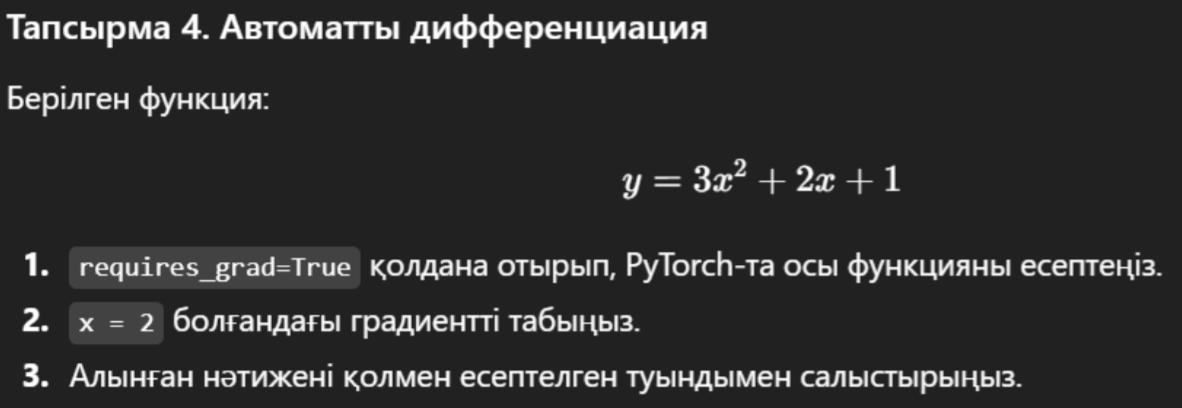

tuyndy=6x+2

x=2

tuyndy=6*2+2=14

In [14]:
x=t.tensor(2.0, requires_grad=True)
y=3*x**2+2*x+1

y.backward()
x.grad

tensor(14.)

## TASK-5

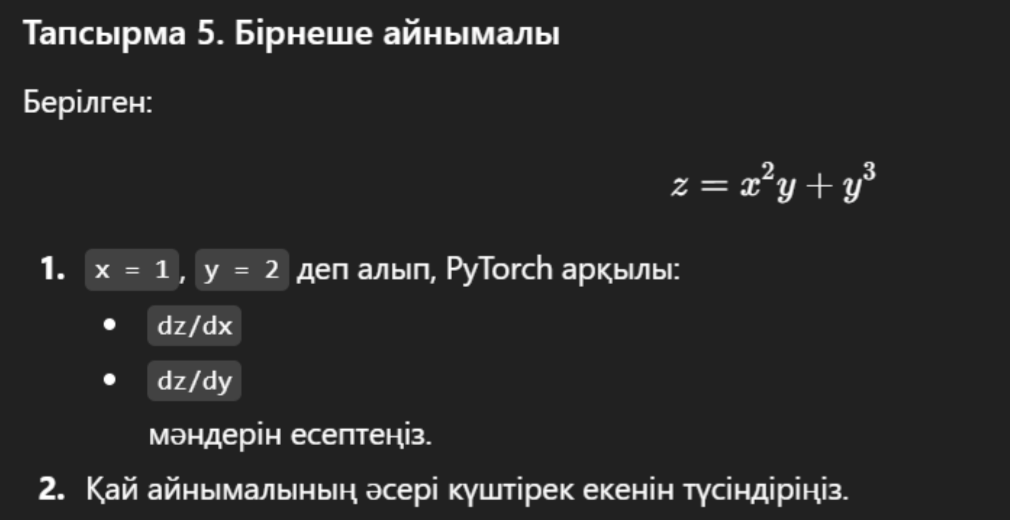

## dz_dx=2xy

## dz_dy=x^2+3y^2

In [15]:

x = t.tensor(1.0, requires_grad=True)
y = t.tensor(2.0, requires_grad=True)

z = x**2 * y + y**3

z.backward()

dz_dx = x.grad.item()
dz_dy = y.grad.item()

print(f"dz/dx at (1, 2) is: {dz_dx}")
print(f"dz/dy at (1, 2) is: {dz_dy}")

dz/dx at (1, 2) is: 4.0
dz/dy at (1, 2) is: 13.0


Variable y has a significantly stronger influence on the value of z at this

specific point because its partial derivative (13) is much higher than 4

## TASK-6

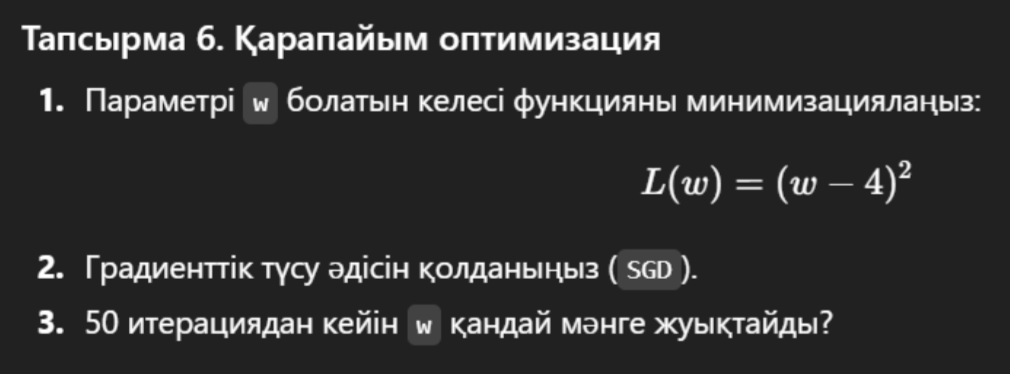

In [16]:
#  requires_grad=True allows PyTorch to compute derivatives
w = t.tensor([0.0], requires_grad=True)

optimizer = t.optim.SGD([w], lr=0.1)

for i in range(50):
    loss = (w - 4)**2

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (i + 1) % 10 == 0:
        print(f"Iteration {i+1}: w = {w.item():.4f}, Loss = {loss.item():.4f}")

print(f"Final value of w after 50 iterations: {w.item()}")

Iteration 10: w = 3.5705, Loss = 0.2882
Iteration 20: w = 3.9539, Loss = 0.0033
Iteration 30: w = 3.9950, Loss = 0.0000
Iteration 40: w = 3.9995, Loss = 0.0000
Iteration 50: w = 3.9999, Loss = 0.0000
Final value of w after 50 iterations: 3.9999430179595947


## TASK-7

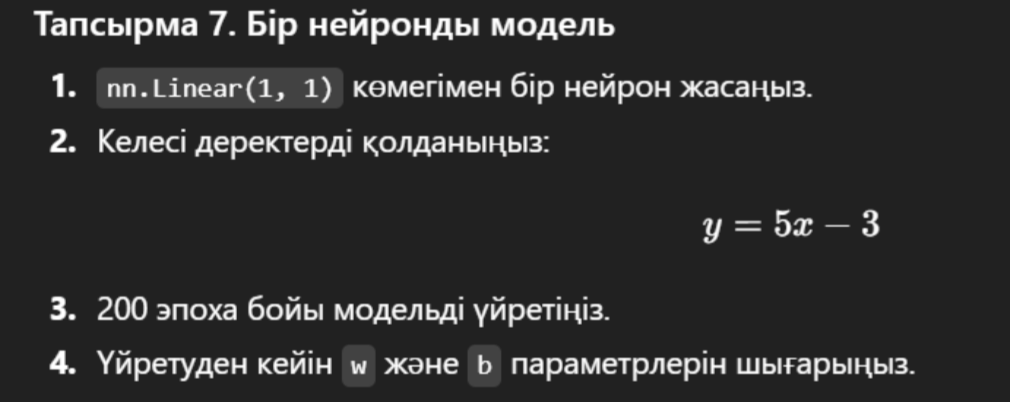

In [17]:
import torch.nn as nn

In [18]:
model = nn.Linear(1, 1)

In [20]:
x_train = t.tensor([[1.0], [2.0], [3.0], [4.0]])
y_train = 5 * x_train - 3

In [21]:
criterion = nn.MSELoss()
optimizer = t.optim.SGD(model.parameters(), lr=0.01)

In [22]:
for epoch in range(200):
    prediction = model(x_train)
    loss = criterion(prediction, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [23]:
w = model.weight.item()
b = model.bias.item()

In [24]:
w

4.12880277633667

In [25]:
b

-0.43857377767562866

## TASK-8

Тапсырма 8. Loss функцияны салыстыру

Бір деректер жиыны үшін:


  - MSELoss

  - L1Loss


Екі loss функциясымен модельді жеке-жеке үйретіңіз.

Қайсысы тезірек convergence береді? Неліктен?


In [26]:
import torch.optim as optim
import matplotlib.pyplot as plt

x = t.linspace(-10, 10, 100).reshape(-1, 1)
y = 2 * x + 1

def train_model(criterion_type, epochs=100, lr=0.01):
    model = nn.Linear(1, 1)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = criterion_type()
    loss_history = []

    for epoch in range(epochs):
        prediction = model(x)
        loss = criterion(prediction, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
    return loss_history

mse_history = train_model(nn.MSELoss)
l1_history = train_model(nn.L1Loss)


print(f"Final MSE Loss: {mse_history[-1]}")
print(f"Final L1 Loss: {l1_history[-1]}")

Final MSE Loss: 0.013484456576406956
Final L1 Loss: 0.6439706683158875


Convergence: MSELoss is faster

Reason: Because its gradient is proportional to the error

Large errors produce large gradients, which result in faster weight updates compared to the constant gradient of L1Loss

## TASK-9

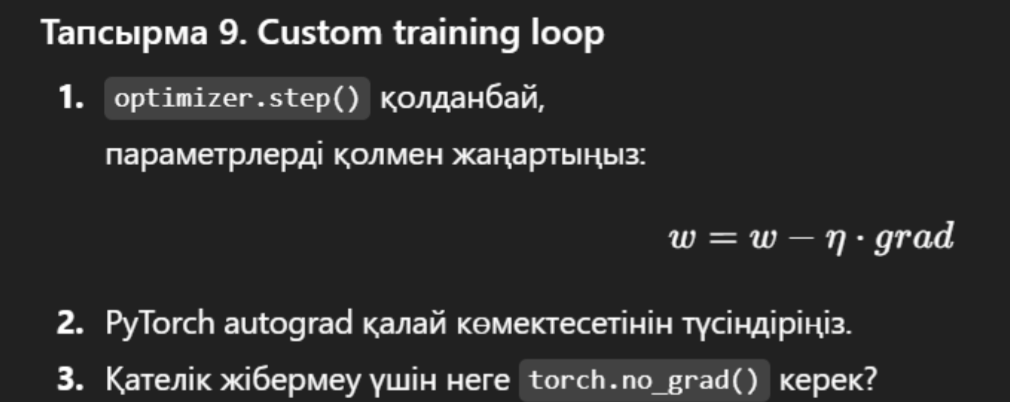

In [28]:

x_train = t.tensor([[1.0], [2.0], [3.0], [4.0]])
y_train = t.tensor([[2.0], [7.0], [12.0], [17.0]]) # y = 5x - 3 формуласы бойынша


w = t.tensor([0.0], requires_grad=True)
b = t.tensor([0.0], requires_grad=True)

learning_rate = 0.01

for epoch in range(200):

    prediction = x_train * w + b
    loss = t.mean((prediction - y_train)**2)
    loss.backward()

    with t.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

print(f"Соңғы нәтиже: w = {w.item():.4f}, b = {b.item():.4f}")

Epoch 40: Loss = 2.3465, w = 3.7266, b = 0.7362
Epoch 80: Loss = 1.8460, w = 3.8726, b = 0.3147
Epoch 120: Loss = 1.4523, w = 4.0000, b = -0.0600
Epoch 160: Loss = 1.1426, w = 4.1131, b = -0.3923
Epoch 200: Loss = 0.8989, w = 4.2133, b = -0.6870
Соңғы нәтиже: w = 4.2133, b = -0.6870


2. PyTorch Autograd қалай көмектеседі?

Autograd — бұл PyTorch-тың автоматты дифференциалдау (туынды табу) функциясы

3. Неге torch.no_grad() керек?

torch.no_grad()  параметрлерді жаңарту кезінде  міндетті түрде қажет